# Machine Learning 2025W — Exercise 0  
### Dataset Description and Exploration (adult)

**Group Members:**  
- Full Name 1  
- Full Name 2  
- Full Name 3  

---


## 1. Setup

In [ ]:
from scipy.io import arff
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree


pd.set_option('display.max_columns', None)

file_path = '../datasets/dataset_adult.arff'

# Read ARFF file, skip lines starting with '%' or '@'
with open(file_path, 'r') as f:
    lines = [line.strip() for line in f if not line.startswith('@') and not line.startswith('%') and line.strip() != '']

# Split each line by comma
data = [line.split(',') for line in lines]

# Column names from ARFF attributes
columns = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week',
           'workclass','education','marital-status','occupation','relationship',
           'race','sex','native-country','class']

# Create DataFrame
df = pd.DataFrame(data, columns=columns)

# Convert numeric columns
numeric_cols = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Convert categorical columns
categorical_cols = [c for c in df.columns if c not in numeric_cols]
df[categorical_cols] = df[categorical_cols].apply(lambda x: x.astype('category'))

df.head(20)

## 3. Basic Information

In [ ]:
df.info()
df.describe()
df.isna().sum()


In [ ]:
df['workclass'].value_counts(dropna=False)
df['occupation'].value_counts(dropna=False)

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display

# 1) Basic counts
n_samples, n_attrs = df.shape
print(f"Samples: {n_samples:,}, Attributes: {n_attrs:,}")

# 2) Per-column diagnostics
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_missing': df.isna().sum(),
    'n_unique': df.nunique(dropna=False)
})

# 3) Heuristic to infer attribute type
def infer_attr_type(col):
    if pd.api.types.is_numeric_dtype(df[col]):
        # numeric: if integer with few unique values -> maybe ordinal; else interval/ratio
        if df[col].nunique(dropna=True) <= 10 and pd.api.types.is_integer_dtype(df[col]):
            return 'ordinal (likely)'
        return 'interval/ratio'
    else:
        # non-numeric -> categorical (nominal)
        return 'nominal (categorical)'

summary['inferred_type'] = [infer_attr_type(c) for c in df.columns]

# show columns sorted by number of missing values (descending)
display(summary.sort_values('n_missing', ascending=False))

## 4. Target Variable (Distribution)

In [ ]:
target_col = 'class'

sns.countplot(x=target_col, data=df)
plt.title('Target distribution (Income <=50K vs >50K)')
plt.xlabel('Income Class (class)')

## 5. Feature Exploration

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(figsize=(12, 8))
plt.suptitle("Numeric Feature Distributions")
plt.show()

cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    plt.figure(figsize=(8, 3))
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
sns.countplot(y='occupation', data=df, order=df['occupation'].value_counts().index)
plt.title('Occupation frequencies')
plt.show()

In [ ]:
df['target_encoded'] = (df['class'] == '>50K').astype(int)
corr = df.corr(numeric_only=True)['target_encoded'].sort_values(ascending=False)
corr
df=df.drop(columns=['target_encoded'])

In [ ]:
df["capital-gain"].hist(bins=20, figsize=(20, 8))

In [ ]:
plt.figure(figsize=(12, 4))
plt.boxplot(df["capital-gain"], vert=False)
plt.title('Boxplot of capital-gain')
plt.show()







## Data Preprocessing

### Preprocess Target Variable

In [ ]:
df['class'] = df['class'].map({'<=50K': 0, '>50K': 1})
sns.countplot(x=df['class'])

We now have changed the target variable 'class' to numerical values where <=50K is represented by 0 and >50K is represented by 1. This will make it easier for machine learning algorithms to process the data.

### Preprocess Input Variables

#### Check for outliers

In [ ]:
plt.figure()
plt.boxplot(df["age"])
plt.title("age") # no outliers

plt.figure()
plt.boxplot(df["fnlwgt"])
plt.title("fnlwgt") # here it doesnt really make sence to look for outliers

plt.figure()
plt.boxplot(df["education-num"])
plt.title("education-num") # no meaningless outliers

plt.figure()
plt.boxplot(df["capital-gain"])
plt.title("capital-gain") # we see outliers here at the top but they are meaningfull so dont remove them
df["capital-gain"].describe()
df[df["capital-gain"] == 99999.000000].shape # there are 244 individuals

plt.figure()
plt.boxplot(df["capital-loss"])
plt.title("capital-loss") # we see some outliers at the top but they are still meaningfull

plt.figure()
plt.boxplot(df["hours-per-week"])
plt.title("hours-per-week") # the spread is quite large but there are no meaningless outliers
df["hours-per-week"].max()# the highest numer is 99, which is quite high but possible with 14,2 hours per day


### Hanlde missing values

In [ ]:
df.isnull().sum()
(df.astype(str)=="?").any()
print((df.astype(str)=="nan").any()) # here we get hits in the columnes "workclass", "occupation", and "native-country"
print((df.astype(str)=="nan").sum()) # workclass: 2799 nan (5,7%), occupation: 2809 nan (5,8%), native-country: 857 nan 48842 (1,8%)


In [ ]:
print(df[(df["workclass"]=="nan")&(df["occupation"]=="nan")&(df["native-country"]=="nan")].shape[0]) #We have 46 (<0,1%) rows where every of the three variables is nan
df[(df["workclass"]=="nan")&(df["occupation"]=="nan")&(df["native-country"]=="nan")]


In [ ]:
print(df.shape)
df = df[~((df["workclass"] == "nan") & 
          (df["occupation"] == "nan") & 
          (df["native-country"] == "nan"))] # remove the rows where all three attributes are na to reduce noise

print(df.shape)

In [ ]:
print(df["workclass"].cat.categories)
df["workclass"]= df["workclass"].replace("nan", "Unknown") # Since 5,7% of the entries are nan, we decided to not just drop the rows but 
df["occupation"]= df["occupation"].replace("nan", "Unknown")
print(df["occupation"].cat.categories)
df["native-country"]= df["native-country"].replace("nan", "Unknown")
print(df["native-country"].cat.categories)


### Categorical data encoding

In [ ]:
def bin_sex(x):
    if x=="Male":
        return 0
    else:
        return 1
df["sex"]= df["sex"].apply(bin_sex) #we encode the attribut sex into an numerical binary attribute
df.head()

In [ ]:
df = pd.get_dummies(df, columns=["workclass","education","marital-status","occupation","relationship","race"], dtype=int) # we used one hot encoding to the attributes "workclass" (8 unique),"education" (16 unique),"marital-status" (7 unique),"occupation" (14 unique),"relationship" (6 unique),"race"(5 unique) since they are all nominal and they have not too many unique values
df.head()

In [ ]:
df[df["native-country"]== "South"].shape

In [ ]:
def map_country_to_region(country):
    north_america = ["United-States", "Canada", "Mexico", "Puerto-Rico", "Outlying-US(Guam-USVI-etc)"]
    europe = ["England", "France", "Germany", "Greece", "Ireland", "Italy", "Poland", "Portugal", "Scotland", "Yugoslavia", "Hungary", "Holand-Netherlands"]
    asia = ["China", "India", "Iran", "Japan", "Philippines", "Vietnam", "Laos", "Thailand", "Taiwan", "Hong", "Cambodia"]
    latin_america = ["Cuba", "Dominican-Republic", "Ecuador", "El-Salvador", "Guatemala", "Haiti", "Honduras", "Jamaica", "Nicaragua", "Peru", "Trinadad&Tobago", "Columbia"]
    south= ["south"] # we decided to give south an own category and dont put it in unknown because there are 115 rows with this entry and just take it as unknown could loos information. Still we dont know wahat south really mean (is it an enty error and sould be "south Africa"/ "south Korea" or is even the global south meant by it)
    unknown = ["Unknown"] 

    if country in north_america:
        return "North America"
    elif country in europe:
        return "Europe"
    elif country in asia:
        return "Asia"
    elif country in latin_america:
        return "Latin America"
    elif country in south:
        return "South"
    else:
        return "Unknown"

df["country_region"] = df["native-country"].apply(map_country_to_region) # we decided to map the countrys to broader regions such that we can use one hot encoding without creating a lot of new columnes. Further many countrys have very little sample size and by grouping them, their information may could better be used by the modles.
df= df.drop(columns=["native-country"]) # now we drop the oldcountry attribute
df = pd.get_dummies(df, columns=["country_region"], dtype=int) # we used one hot encoding to the new attributes country_region

df.head()


### Split data into Test and training set

In [ ]:
X = df.drop("class", axis=1)  # features
y = df["class"]               # class / target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% of data for testing
    random_state=42,     # ensures reproducibility
    stratify=y           # keeps same class proportions in train/test
)



### Making a scaled dataset

In [ ]:
X_train_scaled=X_train.copy()
X_test_scaled= X_test.copy()
scaler = StandardScaler()
numeric_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"] # scale all numerical values
X_train_scaled[numeric_cols]= scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols]= scaler.fit_transform(X_test_scaled[numeric_cols])
X_test_scaled.describe()

# Model Training and Evaluation

We train three classifiers — Decision Tree, KNN, and Naive Bayes — and check how well they predict loan grades.

## Decision Tree Classifier

First we train decision tree clasifiers on multiple combinations of Hyperparameters (the result will be displayed as an dataframe) and inspect the results using specific plots 

In [ ]:

# Hyperparameter lists
max_depths = [5,10, 20, None]
min_splits = [10, 50]
min_leafs = [5, 20]
criterions = ["gini", "entropy"]
weights = [None, "balanced"]

results = []

# Loop through all combinations
for depth, split, leaf, crit, weight in itertools.product(max_depths, min_splits, min_leafs, criterions, weights):
    
    clf = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=split,
        min_samples_leaf=leaf,
        criterion=crit,
        class_weight=weight,
        random_state=42
    )
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:,1]  # probability for AUC
    
    results.append({
        "max_depth": depth,
        "min_samples_split": split,
        "min_samples_leaf": leaf,
        "criterion": crit,
        "class_weight": str(weight),
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average='macro'),
        "weighted_f1": f1_score(y_test, y_pred, average='weighted'),
        "auc": roc_auc_score(y_test, y_prob)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
res_df_ordered= results_df.copy()
res_df_ordered.sort_values(by="macro_f1", ascending=False, inplace=True)
res_df_ordered = res_df_ordered.set_index(["class_weight","criterion","max_depth","min_samples_split","min_samples_leaf"])
res_df_ordered= res_df_ordered.sort_index()
res_df_ordered.head(50)

In [ ]:
# Plots for visualization

## Headmap for the differnt min/max values:
leaf_values = sorted(results_df["min_samples_leaf"].unique())

# Create a single figure with 1 row and N columns (one subplot per leaf value)
fig, axes = plt.subplots(1, len(leaf_values), figsize=(6 * len(leaf_values), 4), sharey=True)

for ax, leaf in zip(axes, leaf_values):
    subset = results_df[results_df["min_samples_leaf"] == leaf]
    heatmap_data = subset.pivot_table(
        values="macro_f1",
        index="max_depth",
        columns="min_samples_split"
    )
    
    sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"min_samples_leaf = {leaf}")
    ax.set_xlabel("min_samples_split")
    ax.set_ylabel("max_depth")

plt.suptitle("Macro F1 by max_depth and min_samples_split for different min_samples_leaf values", y=1.05)
plt.tight_layout()
plt.show()


## Bar chart to show the effect of differnt criterions
sns.barplot(x='class_weight', y='macro_f1', hue='criterion', data=results_df)
plt.title("Effect of class_weight and criterion on Macro F1")
plt.show()

## Plot to show the influnce of weighting the classes
sns.scatterplot(x='weighted_f1', y='macro_f1', hue='class_weight', style='criterion', data=results_df)
plt.title("Weighted F1 vs Macro F1 across Decision Tree variants (class_weight)")
plt.show()



We numerically search the best model dependent on the various evaluation metrics (macro_f1, weighted_f1, accuracy, auc).:

In [ ]:
# Choose the best combination of hyper paramters model:
hyperparams = ["max_depth","min_samples_split","min_samples_leaf","criterion","class_weight"]
# Pick the row with the highest Macro F1
best_model = results_df.loc[results_df['macro_f1'].idxmax()]

print("Optimal hyperparameter combination based on Macro F1:")
print(best_model[hyperparams])

# Pick the row with the highest weighted_f1
best_model = results_df.loc[results_df['weighted_f1'].idxmax()]

print("Optimal hyperparameter combination based on weighted_f1:")
print(best_model[hyperparams])

# Pick the row with the highest accuracy
best_model = results_df.loc[results_df['accuracy'].idxmax()]

print("Optimal hyperparameter combination based on accuracy:")
print(best_model[hyperparams])

# Pick the row with the highest auc
best_model = results_df.loc[results_df['auc'].idxmax()]

print("Optimal hyperparameter combination based on auc:")
print(best_model[hyperparams])


We fit the choosen best model and look what the most importnat features are:

In [ ]:
# Fit the evaluated optical model and get the most important attributes
clf_best = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=10,
    criterion="gini",
    class_weight=None,
    random_state=42
)

clf_best.fit(X_train, y_train)

# Get feature importances
importances = clf_best.feature_importances_

# Combine with feature names
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Top important features:")
print(feature_importance_df.head(10)) 

We compare the evaluation metrics for the unscaled and scaled dataset:

In [ ]:
#Resulting evaulation values for the best selected model
test_pred = clf_best.predict(X_test)

print("Classification report for the UNSCALED data: ")
print(classification_report(y_test, test_pred))


# Apply the best model on the scaled data (shoulnt make any big difference)
clf_best_scaled = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=10,
    criterion="gini",
    class_weight=None,
    random_state=42
)

clf_best_scaled.fit(X_train_scaled, y_train)

test_pred_scaled = clf_best_scaled.predict(X_test_scaled)

print("Classification report for the SCALED data: ")
print(classification_report(y_test, test_pred_scaled))

In [ ]:
#here the tree it too big for a meaningfull representation
plt.figure(figsize=(50, 30))
plot_tree(
    clf_best,
    filled=True,
    rounded=True,
    class_names=[str(cls) for cls in clf_best.classes_],
    feature_names=X_train.columns,
    fontsize=10
)
plt.title("Decision Tree (Best Model)")
plt.show()

# K-NN

#### base model

In [ ]:
import numpy as np
import pandas as pd
import time
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# 1. Keep only numeric features
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

# 2. Scale them
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

# 3. Determine optimal k = sqrt(n)
k = int(np.sqrt(len(X_train_numeric)))
if k % 2 == 0:
    k += 1
print(f"Using k = {k}")

# 4. Train, predict, and measure runtime
start_unscaled = time.time()
knn_unscaled = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn_unscaled.fit(X_train_numeric, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test_numeric)
y_prob_unscaled = knn_unscaled.predict_proba(X_test_numeric)
time_unscaled = time.time() - start_unscaled

start_scaled = time.time()
knn_scaled = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
y_prob_scaled = knn_scaled.predict_proba(X_test_scaled)
time_scaled = time.time() - start_scaled

# 5. Evaluate
def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob[:, 1])  # use probability of positive class
    }

scores_unscaled = evaluate(y_test, y_pred_unscaled, y_prob_unscaled)
scores_scaled = evaluate(y_test, y_pred_scaled, y_prob_scaled)

# 6. Display results
print("\nUnscaled performance:")
for metric, value in scores_unscaled.items():
    print(f"{metric:10}: {value:.4f}")
print(f"Runtime   : {time_unscaled:.3f} seconds")

print("\nScaled performance:")
for metric, value in scores_scaled.items():
    print(f"{metric:10}: {value:.4f}")
print(f"Runtime   : {time_scaled:.3f} seconds")


#### Feature selection. remove highly correlated >0.9

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Keep only numeric features
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

# 2. Compute correlation matrix and remove highly correlated features
corr_matrix = X_train_numeric.corr().abs()

# Upper triangle mask
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop columns with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_train_reduced = X_train_numeric.drop(columns=to_drop)
X_test_reduced = X_test_numeric.drop(columns=to_drop, errors='ignore')

# Show correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

# 3. Scale remaining features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

# 4. Train and compare
knn_unscaled = KNeighborsClassifier(n_neighbors=k)
knn_unscaled.fit(X_train_reduced, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test_reduced))

knn_scaled = KNeighborsClassifier(n_neighbors=k)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

print(f"Removed features: {to_drop}")
print(f"Accuracy (unscaled): {acc_unscaled:.4f}")
print(f"Accuracy (scaled):   {acc_scaled:.4f}")


## Best Model

#### grid search

In [ ]:
from sklearn.model_selection import GridSearchCV
# Base model
knn = KNeighborsClassifier()

# Define hyperparameter grid
param_grid = {
    'n_neighbors': [3, 89, 111, 201, 589],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'p': [1, 2]
}

# Grid search with 5-fold cross-validation
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

# Results
print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

# Evaluate on test set
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test_scaled)
print("Test accuracy:", accuracy_score(y_test, y_pred))

/Users/addonn/Documents/Master/01_Semester1/04_Machine Learning/TUWien-MLExercise/myenv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'metric': 'manhattan', 'n_neighbors': 111, 'p': 1, 'weights': 'distance'}
Best CV accuracy: 0.8381494178459012
Test accuracy: 0.8391393442622951



Model performance on test set:
Accuracy : 0.8386
Precision: 0.8306
Recall   : 0.8386
F1-score : 0.8321


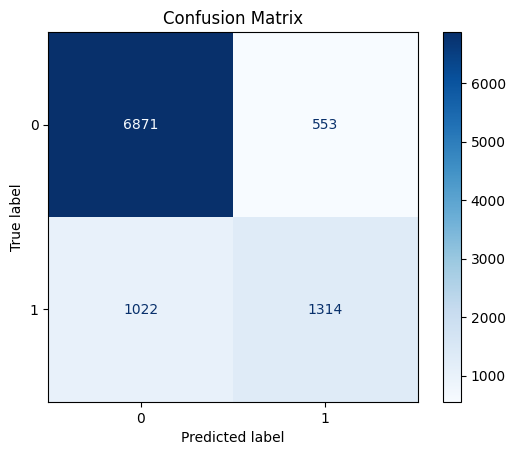


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      7424
           1       0.70      0.56      0.63      2336

    accuracy                           0.84      9760
   macro avg       0.79      0.74      0.76      9760
weighted avg       0.83      0.84      0.83      9760



In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt

# Evaluate best model on test set
y_pred = best_knn.predict(X_test_scaled)

# If probabilities available, compute ROC AUC safely
try:
    y_prob = best_knn.predict_proba(X_test_scaled)
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
except Exception:
    roc_auc = None

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Print all metrics
print("\nModel performance on test set:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
if roc_auc is not None:
    print(f"ROC AUC  : {roc_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=best_knn.classes_).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# Optional full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


## Visualizations

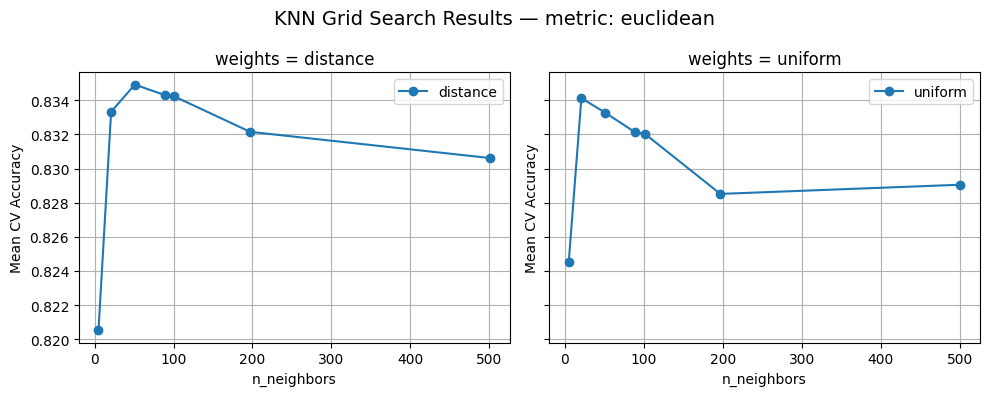

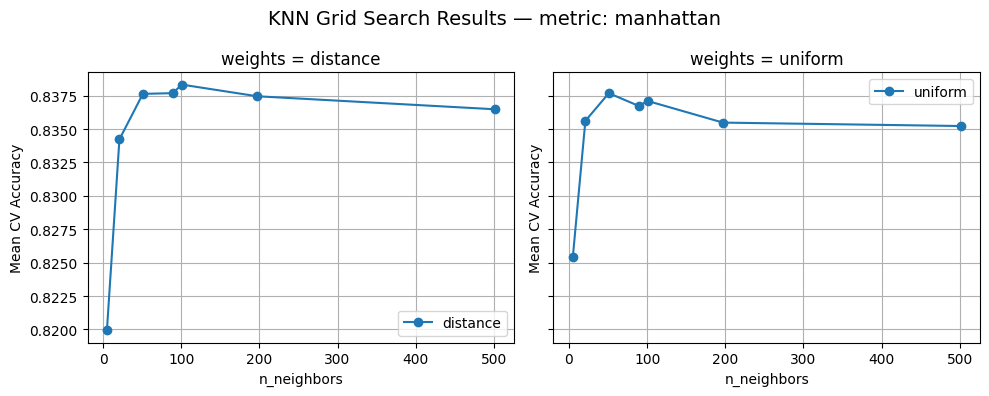

In [ ]:
# ---- Grid Search Visualization ----
results = grid.cv_results_
k_values = sorted(list(set(results['param_n_neighbors'])))
weights = sorted(list(set(results['param_weights'])))
metrics = sorted(list(set(results['param_metric'])))

for metric in metrics:
    fig, axes = plt.subplots(1, len(weights), figsize=(10, 4), sharey=True)
    fig.suptitle(f"KNN Grid Search Results — metric: {metric}", fontsize=14)

    for i, weight in enumerate(weights):
        # Collect mean CV accuracies for each k
        scores = []
        for k in k_values:
            mask = (results['param_n_neighbors'] == k) & \
                   (results['param_metric'] == metric) & \
                   (results['param_weights'] == weight)
            mean_score = np.mean(results['mean_test_score'][mask])
            scores.append(mean_score)

        axes[i].plot(k_values, scores, marker='o', label=f'{weight}')
        axes[i].set_title(f'weights = {weight}')
        axes[i].set_xlabel('n_neighbors')
        axes[i].set_ylabel('Mean CV Accuracy')
        axes[i].grid(True)
        axes[i].legend()

    plt.tight_layout()
    plt.show()